[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cca-cce/osm-comm/blob/main/jnb/skoc62_labs.ipynb)


# Data Analysis Labs


- Load [synthetic dataset](https://github.com/cca-cce/osm-comm/raw/refs/heads/main/csv/skpm20_exam_260213.tsv) and analyze the model below:

[![](https://mermaid.ink/img/pako:eNqVU11v2jAU_SuWUSUqBZbE4SNehVSVPUya9tBKe1hTIRMbsAh2dONQGOK_7wYSIOtemkiJfXzPuefa1weaWqkop0sQ-Yr8eE4MwUdqUKnT1pyQM1aU83PQoxHZvtAFeX2YT74tFhhZEAwVkgjntCulevgyn7ydaR_lGvQ6ursj341UucKPceSXAC3mmSquEXobdHOwskzdLBVOLS3s72-Xw66QWwVutq3IxrUWWdeB0G6mdvjHqAKt3Dd11QamH9Lf-N8Gr1WxdYpWlW__6DxZY87Ftu2TXm9SCbVM_w9kbRBNNRlQ_SeeFnlx-0ybZX0sOFHXM1noLOOdRVy9XuHArhXvpGlaj3tSFCsBIPacDMjgVqLyWLNPz4XNGPNSm1ngHd_325Tw8xT2WYpsjC1BKXMhhPMoGAwbDkrdbNNUwFoBeQSw7812kS72mE5VgbICHPYq8esuweX1yymX7wVeSJoUaKTZt3ct3YqH-e5rYqiH10VLyh2UyqMbBRtRTemhkkuoW6mNSijHoUQjCU3METm5ML-t3TQ0sOVyRflCZAXOylxiW0-1wDu2uaBQtSQ82dI4ylkUnEQoP9Ad5UE87o_G43EcDQeMhT7z6B5RNurHo3g0DgM_iuIwPHr0zymr3x9G0WgY-4NREMUsPP4FnsE59g?type=png)](https://mermaid.live/edit#pako:eNqVU11v2jAU_SuWUSUqBZbE4SNehVSVPUya9tBKe1hTIRMbsAh2dONQGOK_7wYSIOtemkiJfXzPuefa1weaWqkop0sQ-Yr8eE4MwUdqUKnT1pyQM1aU83PQoxHZvtAFeX2YT74tFhhZEAwVkgjntCulevgyn7ydaR_lGvQ6ursj341UucKPceSXAC3mmSquEXobdHOwskzdLBVOLS3s72-Xw66QWwVutq3IxrUWWdeB0G6mdvjHqAKt3Dd11QamH9Lf-N8Gr1WxdYpWlW__6DxZY87Ftu2TXm9SCbVM_w9kbRBNNRlQ_SeeFnlx-0ybZX0sOFHXM1noLOOdRVy9XuHArhXvpGlaj3tSFCsBIPacDMjgVqLyWLNPz4XNGPNSm1ngHd_325Tw8xT2WYpsjC1BKXMhhPMoGAwbDkrdbNNUwFoBeQSw7812kS72mE5VgbICHPYq8esuweX1yymX7wVeSJoUaKTZt3ct3YqH-e5rYqiH10VLyh2UyqMbBRtRTemhkkuoW6mNSijHoUQjCU3METm5ML-t3TQ0sOVyRflCZAXOylxiW0-1wDu2uaBQtSQ82dI4ylkUnEQoP9Ad5UE87o_G43EcDQeMhT7z6B5RNurHo3g0DgM_iuIwPHr0zymr3x9G0WgY-4NREMUsPP4FnsE59g)

- Perform descriptive statistics and data transformations
- Perform bivariate analyses and hypothesis testing
- Perform multivariate analysis, multiple regression


## loading dataset

This code initializes a data science environment by importing **NumPy**, **Pandas**, **Matplotlib**, and **SciPy** for comprehensive analysis. It retrieves the "Palmer Penguins" dataset from a remote GitHub URL, specifically using the `sep="\t"` parameter to correctly parse the **Tab-Separated Values** (TSV) format. The script concludes by calling `df.shape`, which verifies the dataset's dimensions by displaying the total count of rows and columns.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Load the dataset
path = "https://github.com/cca-cce/osm-comm/raw/refs/heads/main/csv/skoc62_labs.tsv"
df = pd.read_csv(path, sep="\t")

print(df.shape)

(500, 9)


This command displays the **structure** of the DataFrame by default. It is used to quickly inspect the data structure, verify that the column headers align with the values, and get a "sneak peek" at the formatting and data types within the set. Use the output to prompt [Google Gemini](https://gemini.google.com) to initialize your data analysis, e.g. **prompt:** "im analyzing a dataframe called df with the following structure, generate code to perform ..."

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   participant_id           500 non-null    object 
 1   advert_variant           500 non-null    object 
 2   product_category         483 non-null    object 
 3   trait_openness           469 non-null    float64
 4   trait_conscientiousness  484 non-null    float64
 5   trait_extraversion       473 non-null    float64
 6   trait_agreeableness      469 non-null    float64
 7   trait_neuroticism        475 non-null    float64
 8   advert_attitude          472 non-null    float64
dtypes: float64(6), object(3)
memory usage: 35.3+ KB


# 1. Descriptive statistics


## use subheadings

Add new text cells like this to write a few sentences explaining the analysis in the associated code cell. Feel free to add subheadings, but don't change the main sections of the notebook. Make note of and explain the findings of your analysis. Visualize your data!

Descriptive Statistics for Advert Attitude:
count    472.000000
mean      13.946819
std        2.058864
min        1.776106
25%       12.890047
50%       13.748285
75%       14.851972
max       29.365980
Name: advert_attitude, dtype: float64


<Figure size 640x480 with 0 Axes>

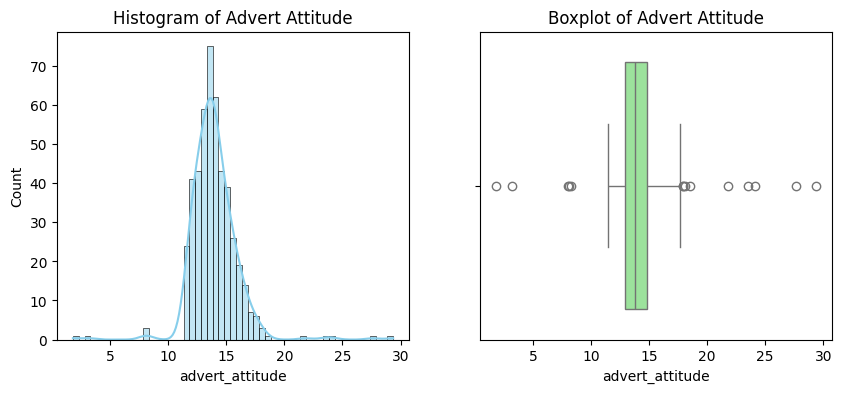

In [3]:
# code cell 1.1, keep this comment, edit content but do not add more code cells
import matplotlib.pyplot as plt
import seaborn as sns

# Descriptive Statistics
print("Descriptive Statistics for Advert Attitude:")
print(df['advert_attitude'].describe())

# Visualization: Histogram and Boxplot
plt.clf()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df['advert_attitude'].dropna(), kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Histogram of Advert Attitude')
sns.boxplot(x=df['advert_attitude'].dropna(), ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot of Advert Attitude')
plt.savefig('advert_attitude_analysis.png')

Frequency Table for Product Category:
product_category
social_events          103
travel_experiential    101
accessories_tech        96
productivity_apps       94
luxury_fashion          89
NaN                     17
Name: count, dtype: int64


/tmp/ipykernel_1116/1044736077.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='product_category', order=order_pc, palette='viridis')


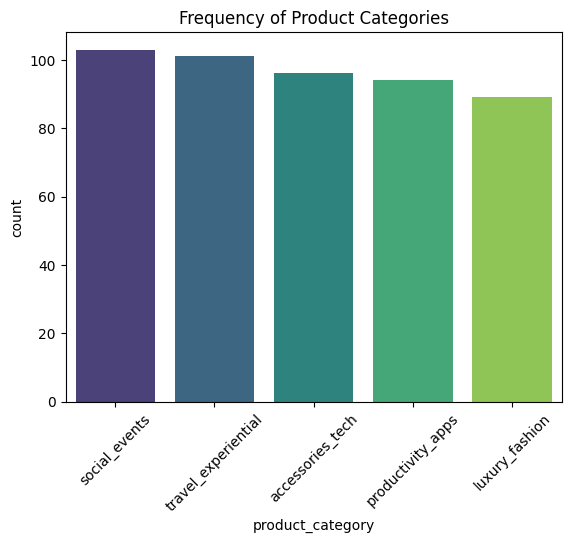

In [4]:
# code cell 1.2, keep this comment, edit content but do not add more code cells
import matplotlib.pyplot as plt
import seaborn as sns

# Frequency Table (including missing values)
print("Frequency Table for Product Category:")
print(df['product_category'].value_counts(dropna=False))

# Visualization: Frequency Bar Chart
plt.clf()
# Sorting categories by frequency for better readability
order_pc = df['product_category'].value_counts().index
sns.countplot(data=df, x='product_category', order=order_pc, palette='viridis')
plt.title('Frequency of Product Categories')
plt.xticks(rotation=45)
plt.savefig('product_category_analysis.png')

Frequency Table for Advert Variant:
advert_variant
treatment    250
control      250
Name: count, dtype: int64


/tmp/ipykernel_1116/2951646371.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='advert_variant', order=order_av, palette='magma')


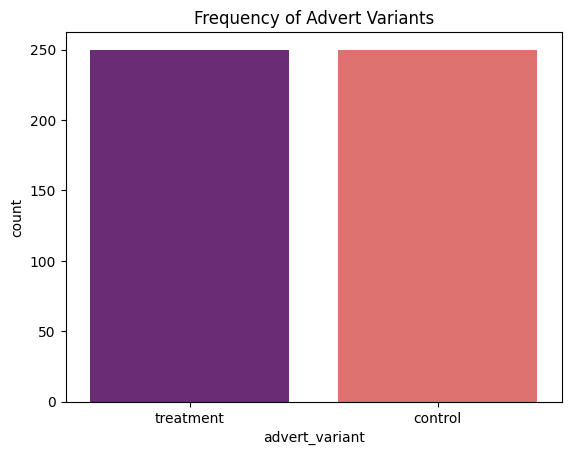

In [5]:
# code cell 1.3, keep this comment, edit content but do not add more code cells
import matplotlib.pyplot as plt
import seaborn as sns

# Frequency Table
print("Frequency Table for Advert Variant:")
print(df['advert_variant'].value_counts())

# Visualization: Frequency Bar Chart
plt.clf()
order_av = df['advert_variant'].value_counts().index
sns.countplot(data=df, x='advert_variant', order=order_av, palette='magma')
plt.title('Frequency of Advert Variants')
plt.savefig('advert_variant_analysis.png')

Descriptive Statistics for Trait Extraversion:
count    473.000000
mean       3.487451
std        0.356879
min        2.333333
25%        3.291667
50%        3.520833
75%        3.708333
max        4.416667
Name: trait_extraversion, dtype: float64


<Figure size 640x480 with 0 Axes>

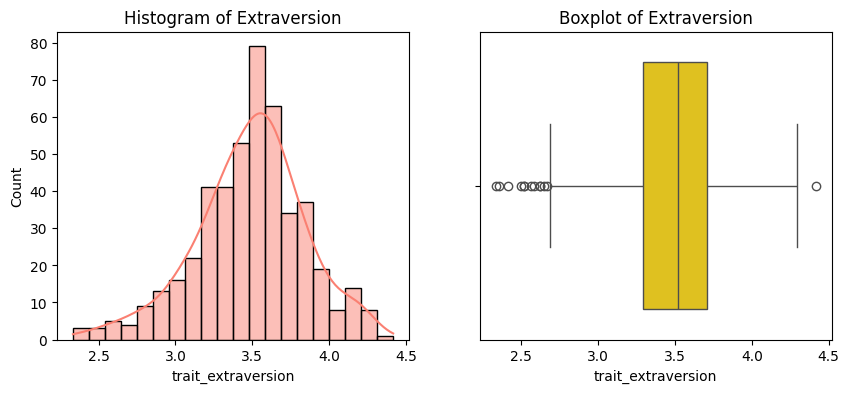

In [6]:
# code cell 1.4, keep this comment, edit content but do not add more code cells
import matplotlib.pyplot as plt
import seaborn as sns

# Descriptive Statistics
print("Descriptive Statistics for Trait Extraversion:")
print(df['trait_extraversion'].describe())

# Visualization: Histogram and Boxplot
plt.clf()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df['trait_extraversion'].dropna(), kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Histogram of Extraversion')
sns.boxplot(x=df['trait_extraversion'].dropna(), ax=axes[1], color='gold')
axes[1].set_title('Boxplot of Extraversion')
plt.savefig('trait_extraversion_analysis.png')

# 2. Data transformations

Total outliers detected: 14
Outlier Details (Prior to Inplace Replacement):
    participant_id  advert_attitude
20           dwsh5        18.062925
72           53z3c        23.505383
100          hy34s         8.238036
107          t34jr        24.138574
132          1b1ym         8.094133
169          atpgb         7.966995
188          flht8        18.482416
252          y6zpl         1.776106
284          psvq3        27.618558
294          3x8gd         3.188141
349          kaav5        29.365980
370          mrxlo        21.790839
439          4tqi4        17.880320
488          stw2l        17.909211

Outliers replaced with median value: 13.7483
Descriptive Statistics for Advert Attitude:
count    472.000000
mean      13.871519
std        1.365179
min       11.454328
25%       12.911710
50%       13.748285
75%       14.688075
max       17.674593
Name: advert_attitude, dtype: float64


<Figure size 640x480 with 0 Axes>

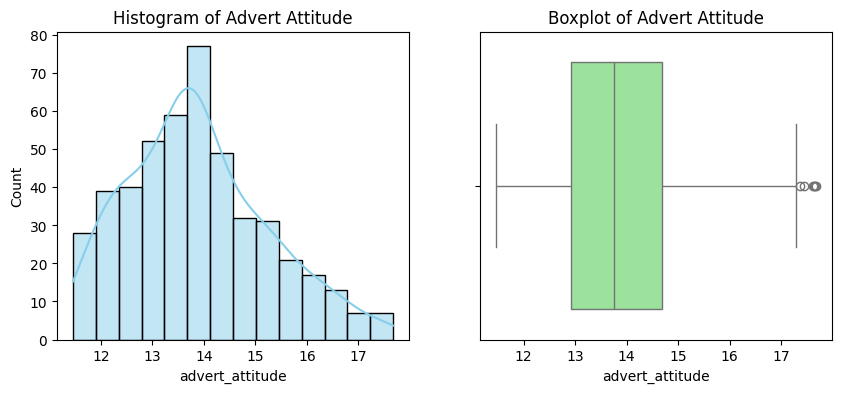

In [7]:
# code cell 2.1, keep this comment, edit content but do not add more code cells
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate IQR and boundaries
# IQR is used to define the range of "normal" values
Q1 = df['advert_attitude'].quantile(0.25)
Q3 = df['advert_attitude'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Identify outliers
# Boolean mask for values outside the [lower_bound, upper_bound] range
outlier_mask = (df['advert_attitude'] < lower_bound) | (df['advert_attitude'] > upper_bound)

# --- Print row number and participant_id for outliers before replacement ---
print(f"Total outliers detected: {outlier_mask.sum()}")
if outlier_mask.any():
    print("Outlier Details (Prior to Inplace Replacement):")
    # Displays the row index and participant_id for identification
    print(df.loc[outlier_mask, ['participant_id', 'advert_attitude']])
else:
    print("No outliers found.")
# ---------------------------------------------------------------------------

# 3. Replace outliers with the median value INPLACE
# This modifies the original 'advert_attitude' column directly
median_val = df['advert_attitude'].median()
df.loc[outlier_mask, 'advert_attitude'] = median_val

print(f"\nOutliers replaced with median value: {median_val:.4f}")

# 4. Visualize the updated original variable with a boxplot
# Descriptive Statistics
print("Descriptive Statistics for Advert Attitude:")
print(df['advert_attitude'].describe())

# Visualization: Histogram and Boxplot
plt.clf()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df['advert_attitude'].dropna(), kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Histogram of Advert Attitude')
sns.boxplot(x=df['advert_attitude'].dropna(), ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot of Advert Attitude')
plt.savefig('advert_attitude_analysis_normalized.png')

In [8]:
# code cell 2.2, keep this comment, edit content but do not add more code cells
import pandas as pd

# 1. Identify missing values
missing_mask = df['product_category'].isna()
num_missing = missing_mask.sum()

# 2. Print row information for missing values
print(f"Number of missing values in 'product_category': {num_missing}")
if num_missing > 0:
    print("Rows with missing 'product_category':")
    print(df.loc[missing_mask, ['participant_id', 'product_category']])

# 3. Calculate the mode value
# We select the first element [0] in case there is a tie
mode_val = df['product_category'].mode()[0]
print(f"\nMode value identified: {mode_val}")

# 4. Replace missing values using direct assignment (avoids FutureWarning)
# This is the modern, recommended way to perform the operation "inplace"
df['product_category'] = df['product_category'].fillna(mode_val)

print("\nMissing values successfully replaced via direct assignment.")

Number of missing values in 'product_category': 17
Rows with missing 'product_category':
    participant_id product_category
26           pc23b              NaN
29           x7zhv              NaN
42           j13ur              NaN
51           jj3ov              NaN
135          p1lh2              NaN
149          twns1              NaN
162          kn9nh              NaN
186          rp9ds              NaN
187          a79oq              NaN
205          bujkl              NaN
223          p3daa              NaN
230          htg93              NaN
238          hmgom              NaN
286          c3j7e              NaN
331          mlc91              NaN
337          rg9vq              NaN
363          j3pzm              NaN

Mode value identified: social_events

Missing values successfully replaced via direct assignment.


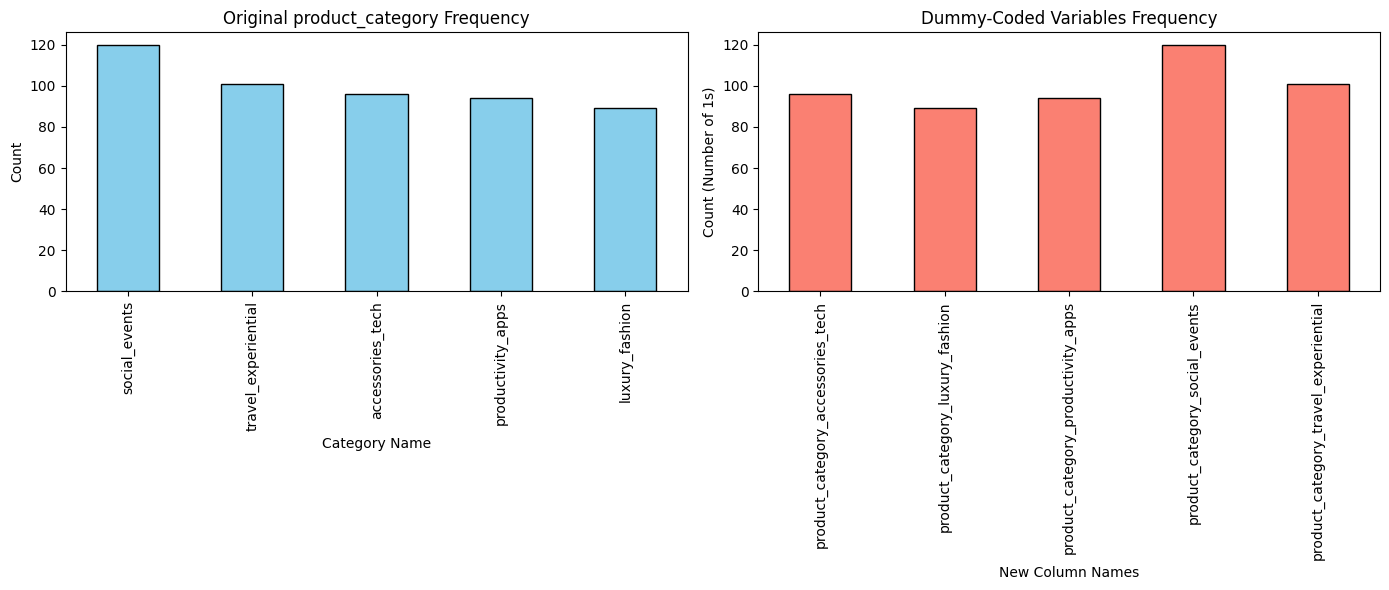

Updated DataFrame with Dummy Columns:
    product_category  product_category_accessories_tech  \
0   accessories_tech                               True   
1      social_events                              False   
2  productivity_apps                              False   
3  productivity_apps                              False   
4  productivity_apps                              False   

   product_category_luxury_fashion  product_category_productivity_apps  \
0                            False                               False   
1                            False                               False   
2                            False                                True   
3                            False                                True   
4                            False                                True   

   product_category_social_events  product_category_travel_experiential  
0                           False                                 False  
1             

In [9]:
# code cell 2.3, keep this comment, edit content but do not add more code cells
import pandas as pd
import matplotlib.pyplot as plt

# 1. Generate Dummy Variables
# prefix_sep='_' will result in columns like product_category_Electronics
df_dummies = pd.get_dummies(df['product_category'], prefix='product_category')

# Add the new dummy columns back to our main dataframe
df = pd.concat([df, df_dummies], axis=1)

# 2. Prepare Data for Visualization
# Get frequency counts for the original categorical variable
original_counts = df['product_category'].value_counts()

# Get frequency counts for the new dummy variables (summing the 1s)
dummy_cols = df_dummies.columns
dummy_counts = df[dummy_cols].sum()

# 3. Create Side-by-Side Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Original Variable Frequency
original_counts.plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Original product_category Frequency')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Category Name')

# Plot 2: New Dummy Variables Frequency
dummy_counts.plot(kind='bar', ax=axes[1], color='salmon', edgecolor='black')
axes[1].set_title('Dummy-Coded Variables Frequency')
axes[1].set_ylabel('Count (Number of 1s)')
axes[1].set_xlabel('New Column Names')

plt.tight_layout()
plt.show()

# Print the first few rows to verify the transformation
print("Updated DataFrame with Dummy Columns:")
print(df[['product_category'] + list(dummy_cols)].head())

In [10]:
# code cell 2.4, keep this comment, edit content but do not add more code cells


# 3. Bivariate analysis


In [11]:
# code cell 3.1, keep this comment, edit content but do not add more code cells


In [12]:
# code cell 3.2, keep this comment, edit content but do not add more code cells


In [13]:
# code cell 3.3, keep this comment, edit content but do not add more code cells


In [14]:
# code cell 3.4, keep this comment, edit content but do not add more code cells


# 4. Hypothesis testing


In [15]:
# code cell 4.1, keep this comment, edit content but do not add more code cells


In [16]:
# code cell 4.2, keep this comment, edit content but do not add more code cells


In [17]:
# code cell 4.3, keep this comment, edit content but do not add more code cells


In [18]:
# code cell 4.4, keep this comment, edit content but do not add more code cells


# 5. Multivariate analysis


In [19]:
# code cell 5.1, keep this comment, edit content but do not add more code cells


In [20]:
# code cell 5.2, keep this comment, edit content but do not add more code cells


In [21]:
# code cell 5.3, keep this comment, edit content but do not add more code cells


In [22]:
# code cell 5.4, keep this comment, edit content but do not add more code cells
